In [ ]:
from google.colab import files
import zipfile
import os

# Upload the zip containing the 'src' directory
print("Please upload src.zip (containing the training and evaluation folders)")
zip_upload = files.upload()

for fn in zip_upload.keys():
  with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall('.')
  print(f"Extracted {fn} to current directory.")

Please upload src.zip (containing the training and evaluation folders)


Saving src.zip to src.zip
Extracted src.zip to current directory.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving delhi_aqi_features.csv to delhi_aqi_features.csv


In [ ]:
import sys
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import io

In [ ]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name()}")

PyTorch 2.11.0+cpu
Device: cpu


In [ ]:
df = pd.read_csv(io.BytesIO(uploaded['delhi_aqi_features.csv']))
df.head()

,datetime,location_lat,location_lon,co,no2,o3,pm10,pm25,so2,aqi,...,wind_from_nw,wind_from_se,diwali_window,stubble_season,winter_flag,rush_hour,night_flag,winter_night_stagnation,stubble_nw_wind,pm25_pm10_ratio
0,2019-01-08 00:00:00,28.5355,77.3178,0.458700,19.591786,36.655121,72.092144,53.864918,4.835449,192.401344,...,1,0,0,0,1,0,1,10.875000,0,0.747168
1,2019-01-08 01:00:00,28.5355,77.3178,0.776717,21.570298,38.989381,76.169286,58.724265,6.258830,204.464234,...,1,0,0,0,1,0,1,11.125000,0,0.770970
2,2019-01-08 02:00:00,28.5355,77.3178,0.684288,30.274686,39.785910,107.791009,67.325879,5.274812,213.428021,...,1,0,0,0,1,0,1,11.375000,0,0.624596
3,2019-01-08 03:00:00,28.5355,77.3178,0.492499,29.543944,51.266713,101.423825,74.447837,6.279582,220.849851,...,1,0,0,0,1,0,1,10.340909,0,0.734027
4,2019-01-08 04:00:00,28.5355,77.3178,0.757127,33.627284,61.958740,92.517704,60.432670,2.786102,206.244572,...,1,0,0,0,1,0,1,11.219512,0,0.653201


In [ ]:
target = "pm25"

In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.ffill().bfill().fillna(0)

In [ ]:
print(f"Shape: {df.shape}")
print(f"Target: {target}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Shape: (43657, 135)
Target: pm25
Date range: 0 to 43656


In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

# Train/Val/Test Split
from src.training.split import temporal_split, scale_data

train_raw, val_raw, test_raw = temporal_split(df, val_frac=0.15, test_frac=0.15)

# Scale using RobustScaler (fit on train only)
train_scaled, val_scaled, test_scaled, feature_scaler, target_scaler = scale_data(
    train_raw, val_raw, test_raw, target=target, method="robust"
)

Temporal Split:
  Train: 2019-01-08 00:00:00 → 2022-07-04 06:00:00 (30,559 rows, 70%)
  Val:   2022-07-04 07:00:00 → 2023-04-03 03:00:00 (6,549 rows, 15%)
  Test:  2023-04-03 04:00:00 → 2024-01-01 00:00:00 (6,549 rows, 15%)
  Scaling method: robust
  Features scaled: 133


In [ ]:
print(f"Scaled train sample — {target}: "
      f"mean={train_scaled[target].mean():.3f}, "
      f"std={train_scaled[target].std():.3f}")

Scaled train sample — pm25: mean=-0.050, std=0.609


In [ ]:
# Create DataLoaders
from src.data.dataset import create_dataloaders

LOOKBACK = 168   # 7 days of hourly input
HORIZON = 24     # 24 hours ahead forecast
BATCH_SIZE = 64

train_loader, val_loader, test_loader, feat_info = create_dataloaders(
    train_scaled, val_scaled, test_scaled,
    target=target,
    lookback=LOOKBACK,
    horizon=HORIZON,
    batch_size=BATCH_SIZE,
    num_workers=0,  # Set 0 for Windows/Colab compatibility
)

DataLoaders created:
  Features: 134
  Lookback: 168h, Horizon: 24h
  Train: 30,368 samples
  Val:   6,358 samples
  Test:  6,358 samples
  Batch: 64


#LSTM Model

In [ ]:
# Create LSTM Model
from src.models.lstm_model import LSTMForecaster, LSTMForecasterWithAttention

model = LSTMForecaster(
    input_size=feat_info["n_features"],
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    horizon=HORIZON,
    bidirectional=False,
)

print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {model.count_parameters():,}")
print(f"\nArchitecture:\n{model}")


Model: LSTMForecaster
Parameters: 293,848

Architecture:
LSTMForecaster(
  (lstm): LSTM(134, 128, num_layers=2, batch_first=True, dropout=0.2)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=24, bias=True)
  )
)


#Training

In [ ]:
# Train the Model
from src.training.train_lstm import train_model, plot_training_history

training_config = {
    "learning_rate": 0.001,
    "weight_decay": 1e-5,
    "max_epochs": 100,
    "early_stopping_patience": 10,
    "grad_clip": 1.0,
    "loss": "huber",
    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "hidden_size": 128,
    "num_layers": 2,
    "dropout": 0.2,
    "batch_size": BATCH_SIZE,
}

model, history = train_model(
    model, train_loader, val_loader,
    config=training_config,
    model_name="lstm_v1",
    use_wandb=False,
)

Training on: cpu
Model parameters: 293,848
Loss function: huber

Epoch |   Train Loss |     Val Loss |         LR |   Time | Status
---------------------------------------------------------------------------
    1 |     0.038613 |     0.024764 |   1.00e-03 | 309.9s | ★ saved
    2 |     0.026509 |     0.022015 |   1.00e-03 | 305.9s | ★ saved
    3 |     0.025110 |     0.021713 |   1.00e-03 | 294.7s | ★ saved
    4 |     0.024422 |     0.021831 |   1.00e-03 | 296.5s | 
    5 |     0.024279 |     0.022002 |   1.00e-03 | 292.4s | 
    6 |     0.023591 |     0.021899 |   1.00e-03 | 292.5s | 
    7 |     0.023054 |     0.022039 |   1.00e-03 | 292.6s | 
    8 |     0.022787 |     0.022317 |   1.00e-03 | 292.4s | 
    9 |     0.023226 |     0.022263 |   1.00e-03 | 290.4s | 
   10 |     0.022313 |     0.022669 |   5.00e-04 | 291.8s | ⚠ patience 7/10
   11 |     0.022083 |     0.022641 |   5.00e-04 | 291.6s | ⚠ patience 8/10
   12 |     0.021878 |     0.022765 |   5.00e-04 | 291.3s | ⚠ patience

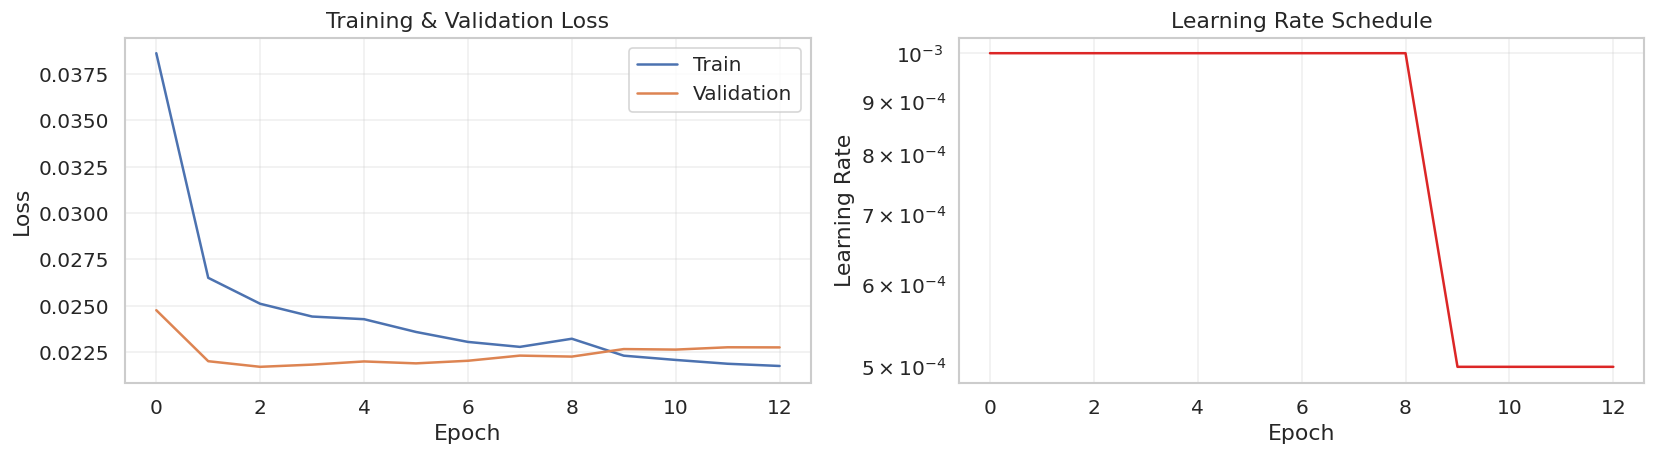

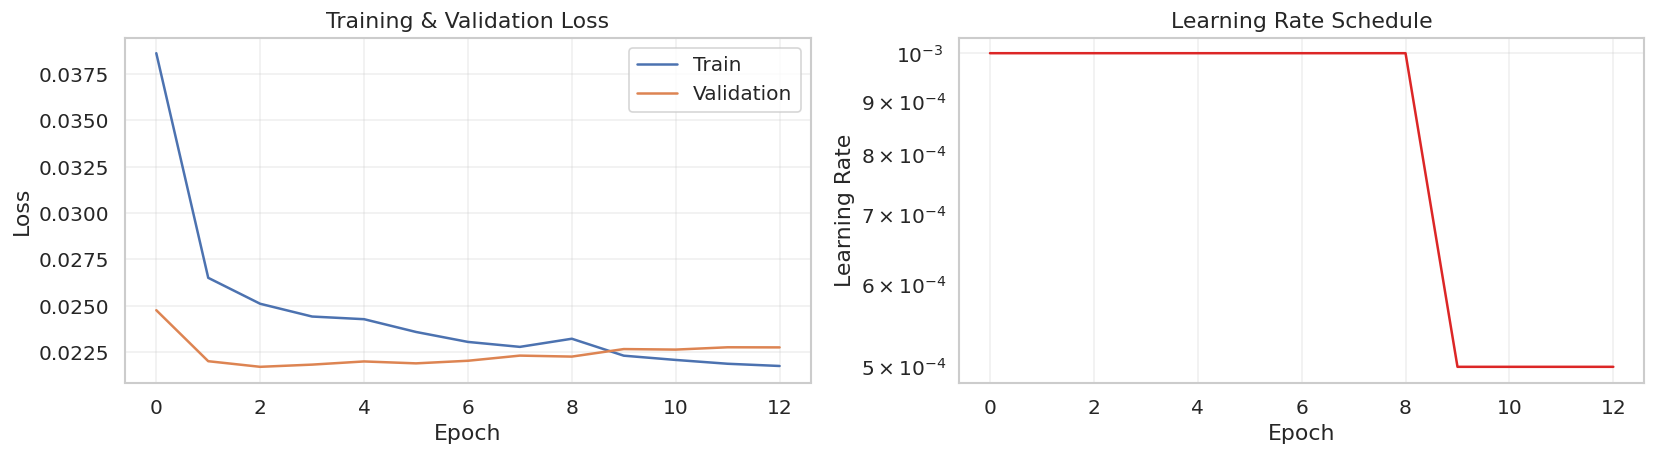

In [ ]:
# Plot Training Curves
plot_training_history(history)

#Evaluation

In [ ]:
# Generate Test Predictions
from src.training.train_lstm import evaluate_model

preds_scaled, actuals_scaled = evaluate_model(model, test_loader, device)

# Inverse transform to original scale
# target_scaler was fit on the target column only
preds_original = target_scaler.inverse_transform(preds_scaled)
actuals_original = target_scaler.inverse_transform(actuals_scaled)

print(f"\nOriginal scale:")
print(f"  Predictions range: [{preds_original.min():.1f}, {preds_original.max():.1f}]")
print(f"  Actuals range: [{actuals_original.min():.1f}, {actuals_original.max():.1f}]")

Test predictions: (6358, 24)
  Pred range: [-1.18, 0.87]
  Actual range: [-1.41, 1.47]

Original scale:
  Predictions range: [9.7, 97.0]
  Actuals range: [0.0, 122.1]


In [ ]:
# Calculate Metrics
from src.evaluation.metrics import calculate_metrics, calculate_metrics_by_horizon

# 1-step ahead metrics (first hour of each window)
metrics_1step = calculate_metrics(actuals_original[:, 0], preds_original[:, 0])
print(f"\n1-Step Ahead (next hour):")
print(f"  MAE:  {metrics_1step['MAE']}")
print(f"  RMSE: {metrics_1step['RMSE']}")
print(f"  MAPE: {metrics_1step['MAPE']}%")

# Full horizon average
all_mae = np.mean([
    calculate_metrics(actuals_original[:, h], preds_original[:, h])["MAE"]
    for h in range(HORIZON)
])
all_mape = np.mean([
    calculate_metrics(actuals_original[:, h], preds_original[:, h])["MAPE"]
    for h in range(HORIZON)
])
print(f"\nAverage across all {HORIZON} horizons:")
print(f"  MAE:  {all_mae:.2f}")
print(f"  MAPE: {all_mape:.2f}%")

# Metrics by horizon
print(f"\nMetrics by forecast horizon:")
horizon_metrics = calculate_metrics_by_horizon(actuals_original, preds_original)
print(horizon_metrics.to_string())


1-Step Ahead (next hour):
  MAE:  7.13
  RMSE: 8.96
  MAPE: 27.26%

Average across all 24 horizons:
  MAE:  7.16
  MAPE: 27.02%

Metrics by forecast horizon:
          MAE  RMSE   MAPE    MASE
horizon                           
1        7.13  8.96  27.26  0.7163
3        7.15  8.98  27.54  0.7184
6        7.15  8.98  26.91  0.7182
12       7.18  9.03  26.67  0.7212
24       7.17  9.00  28.25  0.7201


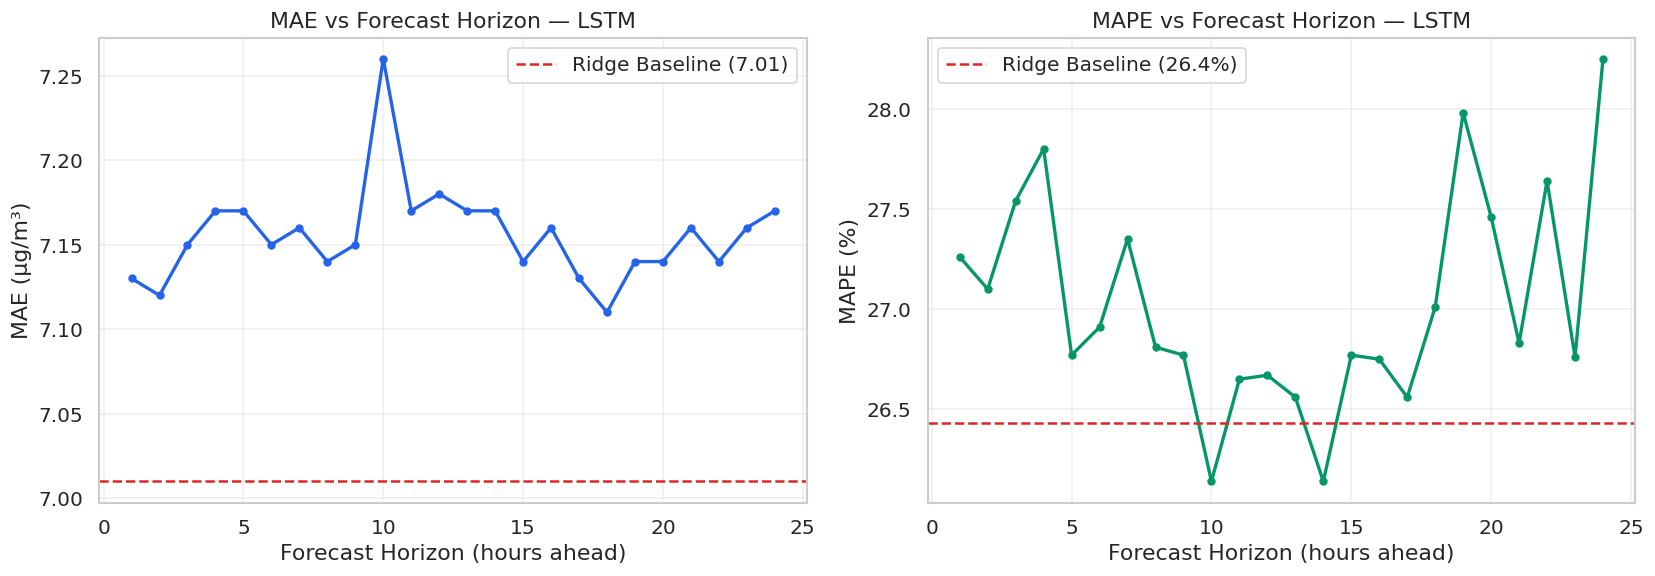

In [ ]:
# Horizon Degradation Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

horizons = range(1, HORIZON + 1)
maes = [calculate_metrics(actuals_original[:, h-1], preds_original[:, h-1])["MAE"]
        for h in horizons]
mapes = [calculate_metrics(actuals_original[:, h-1], preds_original[:, h-1])["MAPE"]
         for h in horizons]

axes[0].plot(horizons, maes, "o-", color="#2563EB", linewidth=2, markersize=4)
axes[0].axhline(y=7.01, color="#DC2626", linestyle="--",
                linewidth=1.5, label="Ridge Baseline (7.01)")
axes[0].set_xlabel("Forecast Horizon (hours ahead)")
axes[0].set_ylabel("MAE (µg/m³)")
axes[0].set_title("MAE vs Forecast Horizon — LSTM")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(horizons, mapes, "o-", color="#059669", linewidth=2, markersize=4)
axes[1].axhline(y=26.43, color="#DC2626", linestyle="--",
                linewidth=1.5, label="Ridge Baseline (26.4%)")
axes[1].set_xlabel("Forecast Horizon (hours ahead)")
axes[1].set_ylabel("MAPE (%)")
axes[1].set_title("MAPE vs Forecast Horizon — LSTM")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

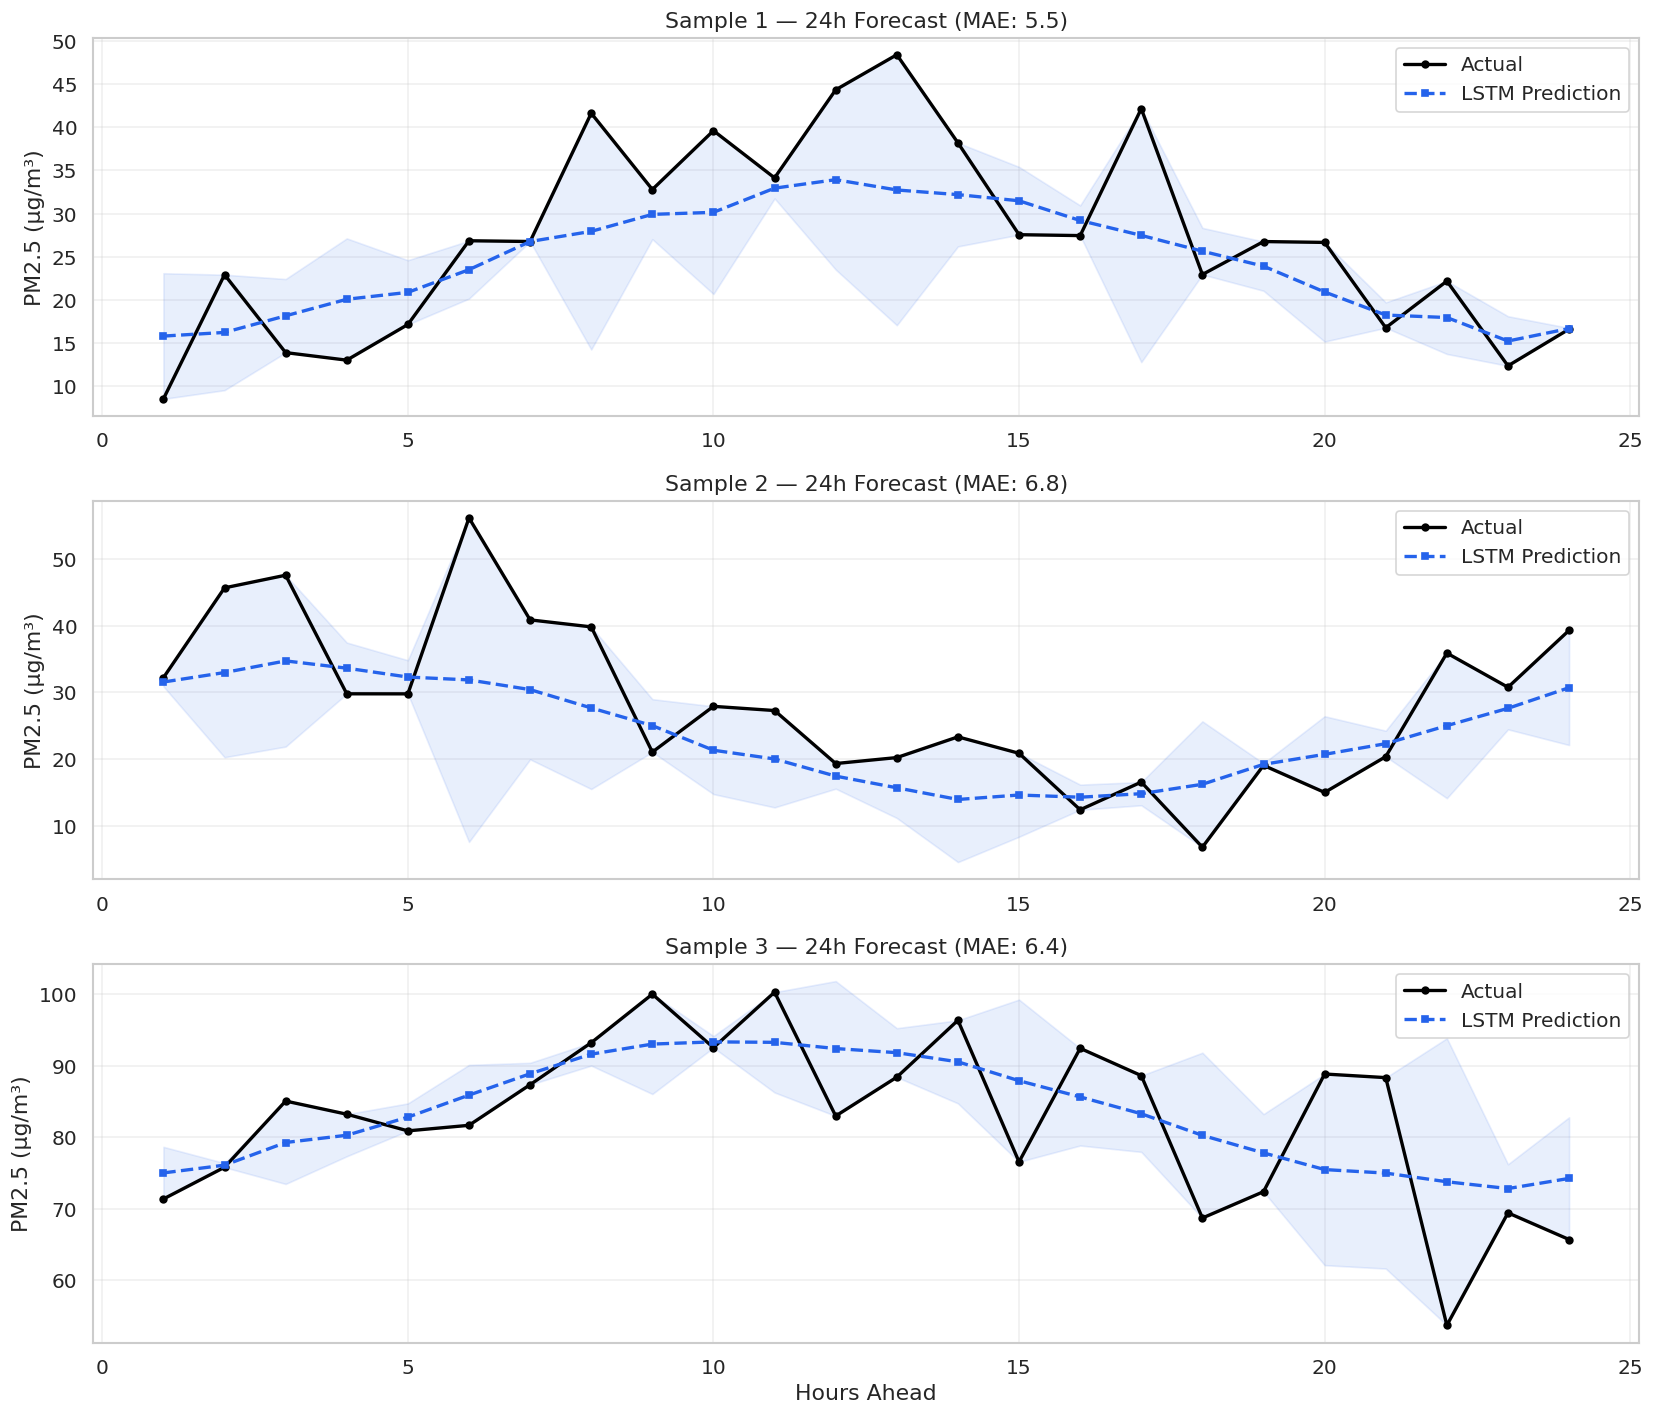

In [ ]:
# Sample Forecast Plots
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Pick 3 random test windows
np.random.seed(42)
sample_indices = np.random.choice(len(actuals_original), 3, replace=False)

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    hours = range(1, HORIZON + 1)

    ax.plot(hours, actuals_original[idx], "o-", color="#000000",
            linewidth=2, markersize=4, label="Actual")
    ax.plot(hours, preds_original[idx], "s--", color="#2563EB",
            linewidth=2, markersize=4, label="LSTM Prediction")

    # Error band
    errors = np.abs(actuals_original[idx] - preds_original[idx])
    ax.fill_between(hours,
                     preds_original[idx] - errors,
                     preds_original[idx] + errors,
                     alpha=0.1, color="#2563EB")

    mae_sample = np.mean(errors)
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_title(f"Sample {i+1} — 24h Forecast (MAE: {mae_sample:.1f})")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Hours Ahead")
plt.tight_layout()
plt.show()

#Comparison with Baselines

In [ ]:
# Summary Table
print(f"""
╔══════════════════════════════════════════════════════════╗
║                 LSTM vs BASELINES                        ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Baselines (1-step ahead):                               ║
║    Naive Persistence:   MAE = 9.98,  MAPE = 35.2%       ║
║    Seasonal Naive:      MAE = 9.98,  MAPE = 35.7%       ║
║    Moving Avg (48h):    MAE = 9.53,  MAPE = 38.0%       ║
║    Linear Ridge:        MAE = 7.01,  MAPE = 26.4%       ║
║                                                          ║
║  LSTM (1-step ahead):                                    ║
║    MAE:  {metrics_1step['MAE']:<8}                               ║
║    MAPE: {metrics_1step['MAPE']:<8}%                              ║
║                                                          ║
║  LSTM (avg across 24h horizon):                          ║
║    MAE:  {all_mae:<8.2f}                                       ║
║    MAPE: {all_mape:<8.2f}%                                      ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")

improvement_mae = (1 - metrics_1step["MAE"] / 7.01) * 100
improvement_naive = (1 - metrics_1step["MAE"] / 9.98) * 100
print(f"MAE improvement over Ridge baseline: {improvement_mae:.1f}%")
print(f"MAE improvement over Naive: {improvement_naive:.1f}%")


╔══════════════════════════════════════════════════════════╗
║                 LSTM vs BASELINES                        ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Baselines (1-step ahead):                               ║
║    Naive Persistence:   MAE = 9.98,  MAPE = 35.2%       ║
║    Seasonal Naive:      MAE = 9.98,  MAPE = 35.7%       ║
║    Moving Avg (48h):    MAE = 9.53,  MAPE = 38.0%       ║
║    Linear Ridge:        MAE = 7.01,  MAPE = 26.4%       ║
║                                                          ║
║  LSTM (1-step ahead):                                    ║
║    MAE:  7.13                                   ║
║    MAPE: 27.26   %                              ║
║                                                          ║
║  LSTM (avg across 24h horizon):                          ║
║    MAE:  7.16                                           ║
║    MAPE: 27.02   %                          

#Optional: LSTM with Attention

In [ ]:
# Train LSTM + Attention (uncomment to run)

model_attn = LSTMForecasterWithAttention(
    input_size=feat_info["n_features"],
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    horizon=HORIZON,
)

print(f"LSTM + Attention parameters: {model_attn.count_parameters():,}")

model_attn, history_attn = train_model(
    model_attn, train_loader, val_loader,
    config=training_config,
    model_name="lstm_attention_v1",
)

# Evaluate
preds_attn_scaled, _ = evaluate_model(model_attn, test_loader, device)
preds_attn = target_scaler.inverse_transform(preds_attn_scaled)

metrics_attn = calculate_metrics(actuals_original[:, 0], preds_attn[:, 0])
print(f"LSTM+Attention 1-step: MAE={metrics_attn['MAE']}, MAPE={metrics_attn['MAPE']}%")

# Attention weight visualization
# Shows which past timesteps the model focuses on
model_attn.eval()
with torch.no_grad():
    sample_x, _ = next(iter(test_loader))
    _ = model_attn(sample_x.to(device))
    attn_weights = model_attn.get_attention_weights()

fig, ax = plt.subplots(figsize=(14, 3))
avg_attn = attn_weights.mean(axis=0)  # average across batch
ax.bar(range(LOOKBACK), avg_attn, color="#7C3AED", alpha=0.7)
ax.set_xlabel("Lookback Hour (0 = 168h ago, 167 = most recent)")
ax.set_ylabel("Attention Weight")
ax.set_title("LSTM Temporal Attention — Which Past Hours Matter Most?")

# Mark key lags
for lag, label in [(LOOKBACK-1, "t-1"), (LOOKBACK-24, "t-24"),
                    (LOOKBACK-48, "t-48"), (0, "t-168")]:
    if 0 <= lag < LOOKBACK:
        ax.axvline(lag, color="#DC2626", linestyle=":", alpha=0.5)
        ax.text(lag, avg_attn.max() * 0.95, label, ha="center", fontsize=8)

plt.tight_layout()
plt.show()

LSTM + Attention parameters: 295,449
Training on: cpu
Model parameters: 295,449
Loss function: huber

Epoch |   Train Loss |     Val Loss |         LR |   Time | Status
---------------------------------------------------------------------------
    1 |     0.039899 |     0.022040 |   1.00e-03 | 284.1s | ★ saved
    2 |     0.023375 |     0.021785 |   1.00e-03 | 284.8s | ★ saved
    3 |     0.022782 |     0.021782 |   1.00e-03 | 283.6s | ★ saved
    4 |     0.022515 |     0.021464 |   1.00e-03 | 282.9s | ★ saved
    5 |     0.022332 |     0.021681 |   1.00e-03 | 281.9s | 
    6 |     0.022160 |     0.022031 |   1.00e-03 | 281.6s | 
    7 |     0.022015 |     0.022386 |   1.00e-03 | 282.9s | 
    8 |     0.021816 |     0.022058 |   1.00e-03 | 285.0s | 
    9 |     0.021636 |     0.022527 |   1.00e-03 | 283.4s | 
   10 |     0.021420 |     0.022698 |   1.00e-03 | 282.0s | 
   11 |     0.021003 |     0.023351 |   5.00e-04 | 281.0s | ⚠ patience 7/10
   12 |     0.020873 |     0.023263 |   5